In [1]:
# Libraries
import sys
sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt
import json
import torch
from torch import nn
from data_processors import *
from scipy.stats import sem, t
import os
from tqdm import tqdm
from policies import DeepGaussianPolicy
from envs import PendulumEnv
from data_processors import KernelDataProcessor
import copy
import math
import imageio
import random
import pandas as pd
import seaborn as sns

/home/tedeschi_bpo/miniconda3/envs/RlEnv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Funzione per caricare i dati da un percorso
def load_trials(base_path, n_exp):
    trial_performances = []
    for i in range(n_exp):
        trial_path = os.path.join(base_path, f"trial_{i}")
        if os.path.isdir(trial_path):
            try:
                file_path = os.path.join(trial_path, "results.json")
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    trial_performances.append(data["performance"])
            except (FileNotFoundError, json.JSONDecodeError) as e:
                print(f"Errore nel leggere {file_path}: {e}")
    return np.array(trial_performances)  # Converte in array per calcoli successivi

In [4]:
paths = [
    "/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl4_retrain/std{0.1}kl{0}_07_28-03_11_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_01_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl4_retrain/std{5}kl{0}_07_28-04_20_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_5_noise_00",
    #"/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl4_retrain/std{10}kl{0}_07_28-06_05_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_10_noise_00"

]

In [5]:
# Lista per memorizzare le performance per ogni set
all_performances = []

for path in paths:
    performances = load_trials(path, n_exp=10)
    if performances.size > 0:
        all_performances.append(performances)

lab = ['std 0.1', 'std 5', 'std 10']
print(len(all_performances))

2


-1.531977216633115
-2.4499190783859577


<Figure size 640x480 with 0 Axes>

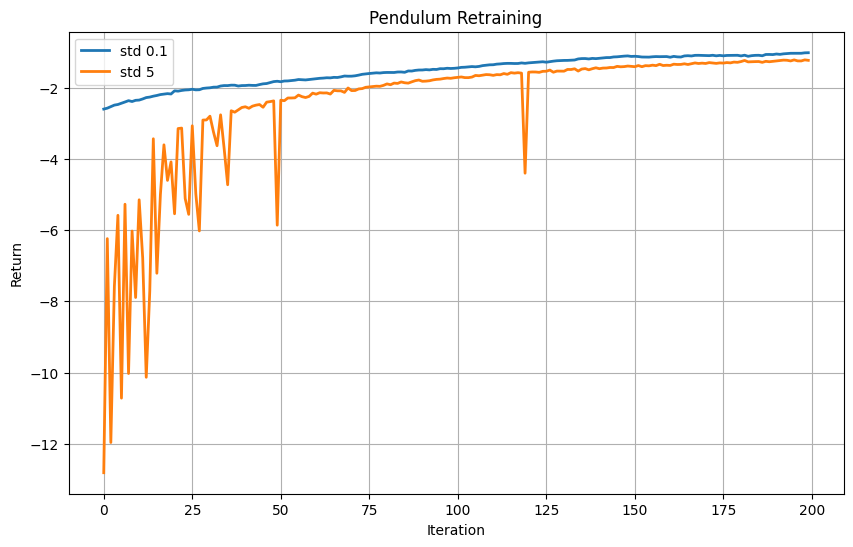

In [6]:
# Plot dei grafici
plt.clf()
# plt.figure(figsize=(6.5, 4.5))
plt.figure(figsize=(10, 6))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        std_performance = np.std(performances, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, linewidth=2, label = lab[i])

        # Plot dell'intervallo di confidenza
        lower = mean_performance-(std_performance)*1.96/np.sqrt(performances.shape[0])
        higher = mean_performance+(std_performance)*1.96/np.sqrt(performances.shape[0])

        plt.fill_between(
            range(len(mean_performance)),
            lower,
            higher,
            alpha=0.2
        )

        print(np.mean(mean_performance))
        # print(np.mean(lower))
        # print(np.mean(higher))

# Etichette e titolo
plt.title("Pendulum Retraining")
plt.xlabel("Iteration")
plt.ylabel("Return")

plt.legend()
plt.grid()
# plt.ylim(bottom=-80)
# plt.xlim(right=80)
# Salva e mostra il grafico
# plt.savefig("dam_1825_b10_g999.pdf", format='pdf')
plt.show()

In [3]:
def load_cost(trial_path):
    costs = []
    if os.path.isdir(trial_path):
        try:
            file_path = os.path.join(trial_path, "results.json")
            with open(file_path, 'r') as file:
                data = json.load(file)
                costs.append(data["cost"])
        except (FileNotFoundError, json.JSONDecodeError) as e:
            print(f"Errore nel leggere {file_path}: {e}")
    return np.array(costs)  

In [12]:
HORIZON = 200
GAMMA = 0.99
FRICTION = 0.3
STD_DEV = 0.25

NUM_EPISODES = 200

START = "down"
SEED = 42  
random.seed(SEED)
np.random.seed(SEED)

env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = FRICTION, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )

policies = [
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl4_retrain/std{0.1}kl{0}_07_28-03_11_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_01_noise_00/trial_0", 0.1, 0],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl4_retrain/std{5}kl{0}_07_28-04_20_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_5_noise_00/trial_0", 5, 0],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl4_retrain/std{10}kl{0}_07_28-06_05_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_10_noise_00/trial_0", 10, 0],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl2_retrain/std{0.75}kl{0}_07_25-23_34_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0", 0.75, 0],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl2_retrain/std{1.5}kl{0}_07_26-02_13_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0", 1.5, 0],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl3_retrain/std{2}kl{0}_07_27-03_40_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_2_noise_00/trial_0", 2, 0],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl3_retrain/std{3}kl{0}_07_27-05_25_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_3_noise_00/trial_0", 3, 0],
    #["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl3_retrain/std{4}kl{0}_07_27-07_15_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_4_noise_00/trial_0", 4, 0]
    #["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl4_retrain/std{0.1}kl{25}_07_28-07_50_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_01_noise_00/trial_0", 0.1, 25],
    #["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl4_retrain/std{5}kl{25}_07_28-08_56_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_5_noise_00/trial_0", 5, 25],
    #["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl4_retrain/std{10}kl{25}_07_28-10_43_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_10_noise_00/trial_0", 10, 25],
    #["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl4_retrain/std{0.1}kl{-30}_07_28-12_31_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_01_noise_00/trial_0", 0.1, -30],
    #["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl4_retrain/std{5}kl{-30}_07_28-13_31_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_5_noise_00/trial_0", 5, -30],
    #["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl4_retrain/std{10}kl{-30}_07_28-14_53_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_10_noise_00/trial_0", 10, -30]

   


]
data = []

for policy in policies :
    random.seed(SEED)
    np.random.seed(SEED)        
    pol = DeepGaussianPolicy(
                parameters=np.load(policy[0] +"/policy_params.npy"),
                output_size=a_dim,
                model=copy.deepcopy(net),
                model_desc=copy.deepcopy(model_desc),
                std_dev=STD_DEV,
                std_decay=0,
                std_min=1e-6
            )
    dp = KernelDataProcessor()

    all_episode_rewards = []
    for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
        episode_rewards = []
        done = False
        env.reset(options={"start": START}, seed = i)
        for t in range(HORIZON): # iterate over the steps until termination
            obs = env.state
            obs = dp.transform(obs)
            action = pol.draw_action(obs)
            obs, rew, done, _ = env.step(action)
            episode_rewards.append(rew * GAMMA ** t)
            if done:
                break
        all_episode_rewards.append(sum(episode_rewards))

    mean_episode_reward = np.mean(all_episode_rewards)
    std_episode_reward = np.std(all_episode_rewards)
    print("Mean reward:", mean_episode_reward,
            "Std reward:", std_episode_reward)


    # plt.plot(all_episode_rewards, linewidth=2, label="reward")
    # plt.title("Cartpole Reward")
    # plt.xlabel("episode")
    # plt.ylabel("Return")
    # plt.grid()

    # plt.title("Pendulum Cost")
    # plt.xlabel("episode")
    # plt.ylabel("Return")
    # plt.grid()
    # plt.legend()
    # plt.show
    mean_cost = np.mean(load_cost(policy[0]))

    data.append({
        'mean_reward' : mean_episode_reward,
        'std_reward' : std_episode_reward,
        'behavioural_std' : policy[1],
        'kl_coefficient' : policy[2],
        'cost' : mean_cost

    })


100%|██████████| 200/200 [00:10<00:00, 19.01it/s]


Mean reward: -393.27323924561165 Std reward: 119.35766343936298


100%|██████████| 200/200 [00:13<00:00, 14.88it/s]


Mean reward: -392.91632016491087 Std reward: 118.72330473105445


100%|██████████| 200/200 [00:15<00:00, 13.05it/s]


...

Mean reward: -393.22402288348735 Std reward: 119.37539625164518


100%|██████████| 200/200 [00:11<00:00, 17.99it/s]


Mean reward: -393.20698500649735 Std reward: 119.39627018892594


100%|██████████| 200/200 [00:11<00:00, 17.52it/s]

Mean reward: -393.183652816489 Std reward: 119.40035644171674


In [13]:
df = pd.DataFrame(data)
df

,mean_reward,std_reward,behavioural_std,kl_coefficient,cost
0,-393.273239,119.357663,0.10,0,-1.543290
1,-392.916320,118.723305,5.00,0,-3.083072
2,-393.119841,123.552553,10.00,0,-19.133500
3,-393.202312,119.367481,0.75,0,-1.556957
4,-393.224023,119.375396,1.50,0,-1.633471
5,-393.206985,119.396270,2.00,0,-1.645315
6,-393.183653,119.400356,3.00,0,-1.759132


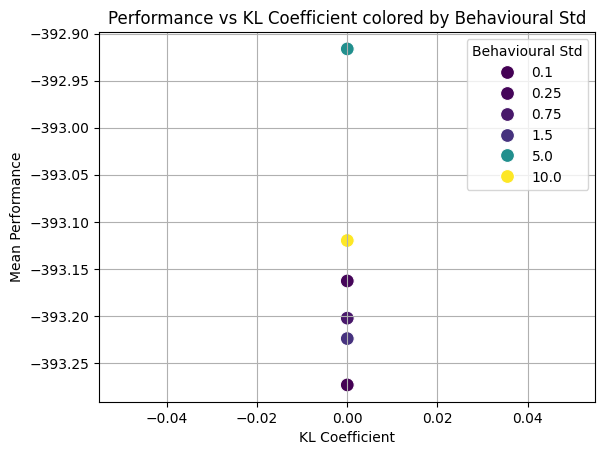

In [6]:
sns.scatterplot(
    data=df,
    x='kl_coefficient',
    y='mean_reward',
    hue='behavioural_std',  # color by this column
    palette='viridis',      # or try: 'coolwarm', 'plasma', etc.
    s=100                   # point size
)

plt.xlabel("KL Coefficient")
plt.ylabel("Mean Performance")
plt.title("Performance vs KL Coefficient colored by Behavioural Std")
plt.grid(True)
plt.legend(title="Behavioural Std")
plt.show()

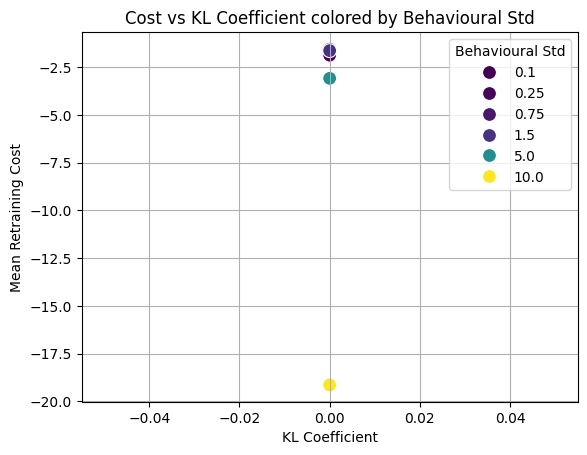

In [7]:
sns.scatterplot(
    data=df,
    x='kl_coefficient',
    y='cost',
    hue='behavioural_std',  # color by this column
    palette='viridis',      # or try: 'coolwarm', 'plasma', etc.
    s=100                   # point size
)

plt.xlabel("KL Coefficient")
plt.ylabel("Mean Retraining Cost")
plt.title("Cost vs KL Coefficient colored by Behavioural Std")
plt.grid(True)
plt.legend(title="Behavioural Std")
plt.show()

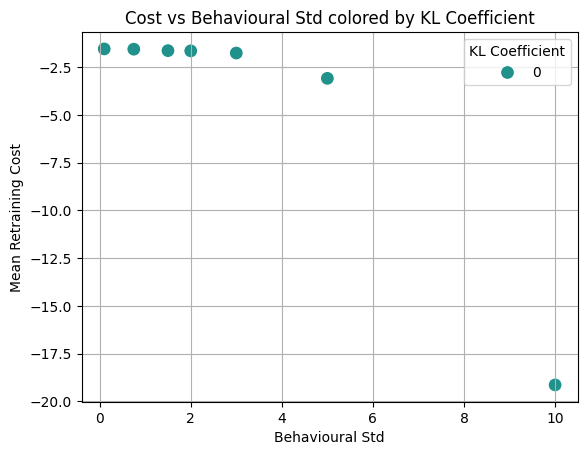

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x='behavioural_std',  # X-axis: behavioural_std
    y='cost',              # Y-axis: cost
    hue='kl_coefficient',  # Color points by kl_coefficient
    palette='viridis',
    s=100
)

plt.xlabel("Behavioural Std")
plt.ylabel("Mean Retraining Cost")
plt.title("Cost vs Behavioural Std colored by KL Coefficient")
plt.grid(True)
plt.legend(title="KL Coefficient")
plt.show()
